<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Student_Academic_Performance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Academic Performance Dataset


It’s a clean and comprehensive collection of information from 2000 students, designed to help us understand what factors might influence their final exam results.

Each student record gives us a clear picture: we have their attendance percentage, scores from two internal tests (out of 40), their assignment performance (out of 10), and even their reported daily study hours. Crucially, the dataset also includes their final exam marks (out of 100), which is often the ultimate measure of academic success.

From our initial exploration, we can see that students generally have good attendance, averaging around 85%, and perform quite consistently on their internal tests and assignments. Daily study hours vary, which is expected, but the range of final exam marks (from 25 to a perfect 100) tells us there's a good spread in overall student performance.

Looking deeper, the correlations reveal some interesting insights. Not surprisingly, there's a strong positive relationship between internal test scores and final exam marks – students who do well on their internal assessments tend to perform better in the final exam. Attendance, assignment scores, and even daily study hours also show positive connections, suggesting that consistent effort across these areas contributes significantly to overall academic achievement. This dataset offers a solid foundation for building predictive models to understand and potentially improve student outcomes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d sonalshinde123/student-academic-performance-dataset

# Unziping the downloaded file
!unzip student-academic-performance-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sonalshinde123/student-academic-performance-dataset
License(s): CC0-1.0
  0% 0.00/14.6k [00:00<?, ?B/s]
100% 14.6k/14.6k [00:00<00:00, 49.3MB/s]
Archive:  student-academic-performance-dataset.zip
  inflating: Final_Marks_Data.csv    


In [4]:
df = pd.read_csv('Final_Marks_Data.csv')
df.head(11)

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66
5,S1005,100,34,34,7,3,79
6,S1006,96,40,36,8,3,83
7,S1007,83,39,37,7,3,77
8,S1008,91,30,37,8,2,71
9,S1009,87,27,37,8,3,61


In [5]:
df.tail(11)

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
1989,S2989,87,27,35,8,2,70
1990,S2990,86,37,33,8,3,66
1991,S2991,70,28,29,7,3,44
1992,S2992,89,32,39,8,3,71
1993,S2993,88,30,25,7,2,49
1994,S2994,97,40,38,9,4,81
1995,S2995,82,31,28,6,2,52
1996,S2996,78,38,27,7,2,57
1997,S2997,78,30,33,9,2,61
1998,S2998,82,29,40,8,3,59


In [6]:
df.shape

(2000, 7)

In [7]:
df.columns

Index(['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)',
       'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)',
       'Daily Study Hours', 'Final Exam Marks (out of 100)'],
      dtype='object')

In [8]:
df.dtypes

,0
Student_ID,object
Attendance (%),int64
Internal Test 1 (out of 40),int64
Internal Test 2 (out of 40),int64
Assignment Score (out of 10),int64
Daily Study Hours,int64
Final Exam Marks (out of 100),int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,2000,2000,S2983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance (%),2000.0,NaN,NaN,NaN,84.8915,7.758855,52.0,80.0,85.0,90.0,100.0
Internal Test 1 (out of 40),2000.0,NaN,NaN,NaN,32.1155,4.563504,18.0,29.0,32.0,35.0,40.0
Internal Test 2 (out of 40),2000.0,NaN,NaN,NaN,32.4645,4.522827,16.0,29.0,33.0,36.0,40.0
Assignment Score (out of 10),2000.0,NaN,NaN,NaN,7.507,1.021015,4.0,7.0,8.0,8.0,10.0
Daily Study Hours,2000.0,NaN,NaN,NaN,2.8235,0.608714,1.0,2.0,3.0,3.0,5.0
Final Exam Marks (out of 100),2000.0,NaN,NaN,NaN,64.855,11.341265,25.0,58.0,65.0,73.0,100.0


In [11]:
df.isnull().sum()

,0
Student_ID,0
Attendance (%),0
Internal Test 1 (out of 40),0
Internal Test 2 (out of 40),0
Assignment Score (out of 10),0
Daily Study Hours,0
Final Exam Marks (out of 100),0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

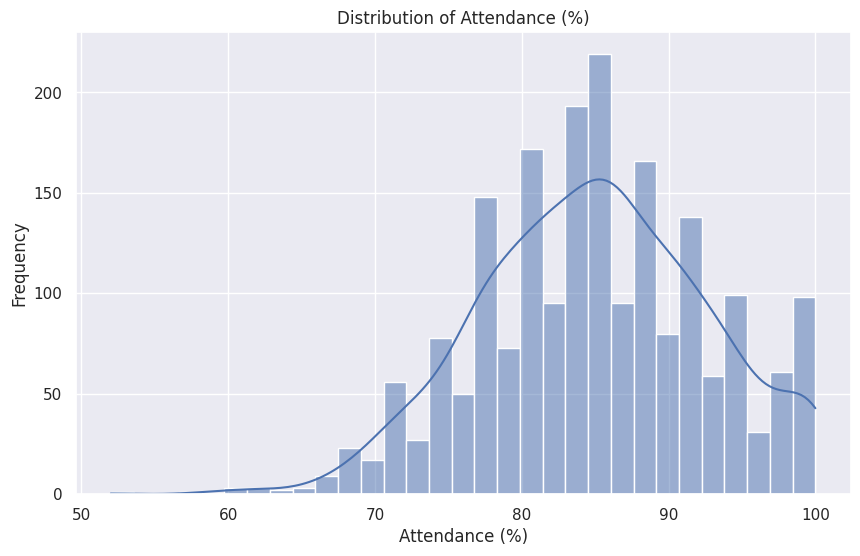

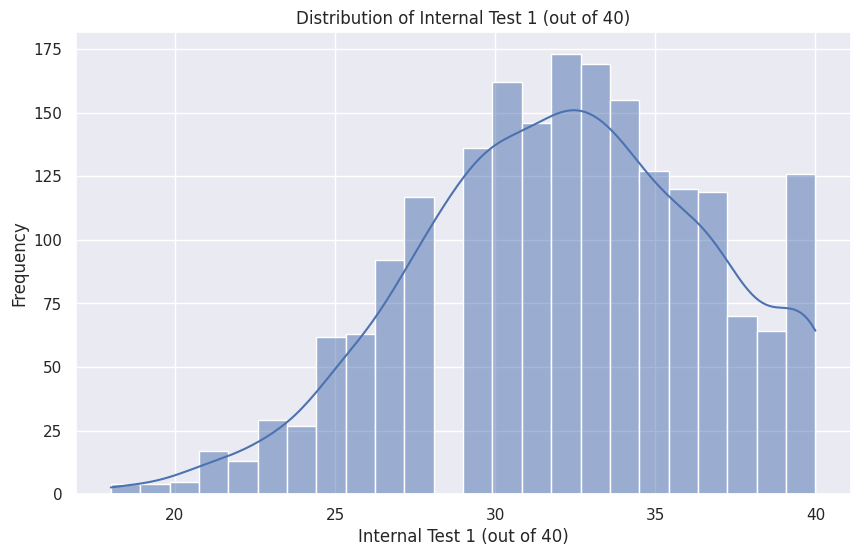

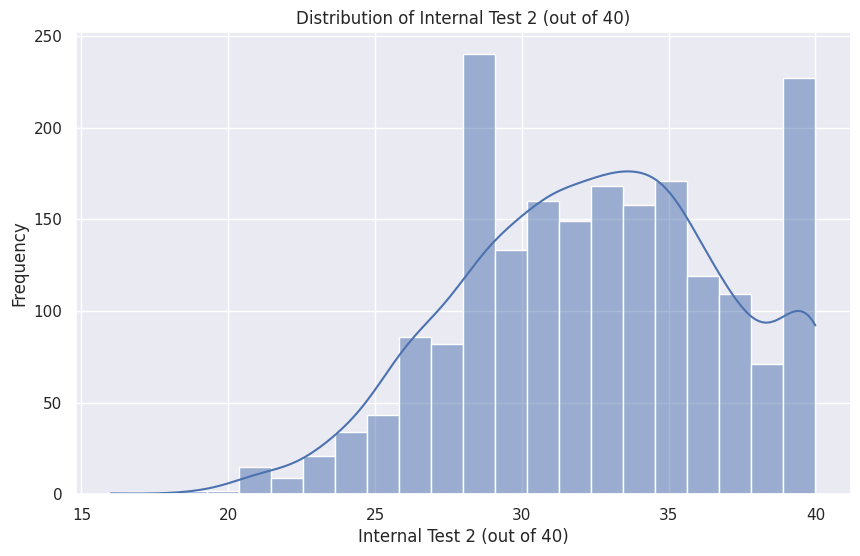

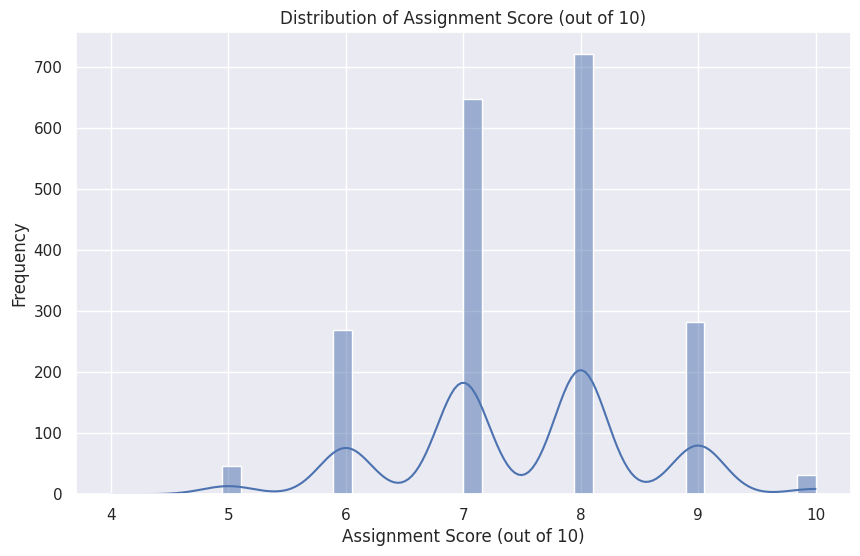

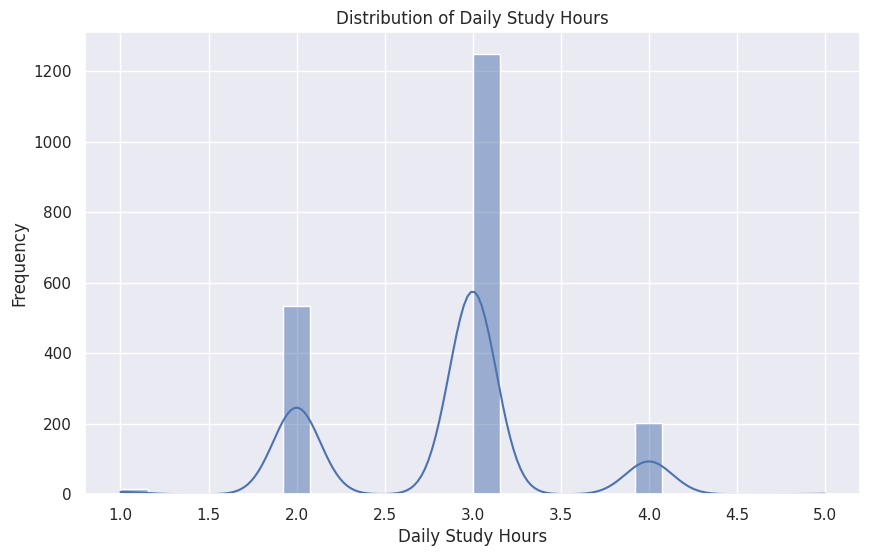

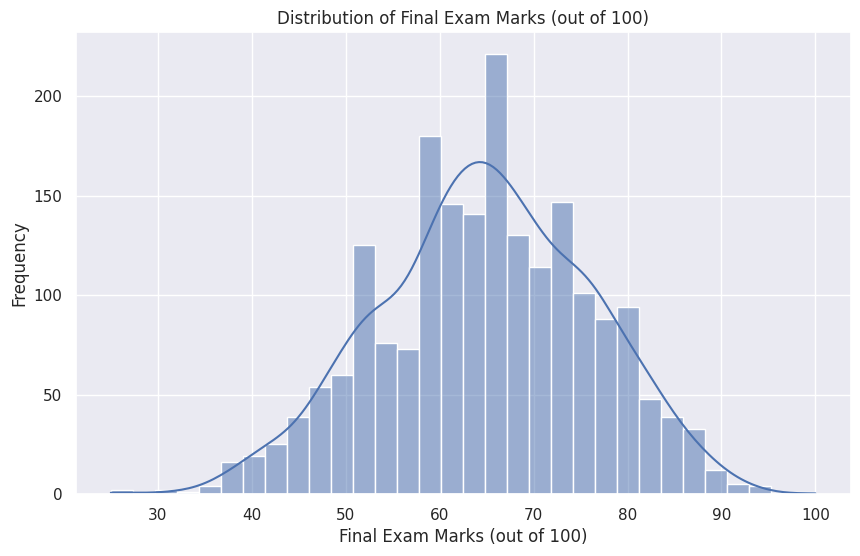

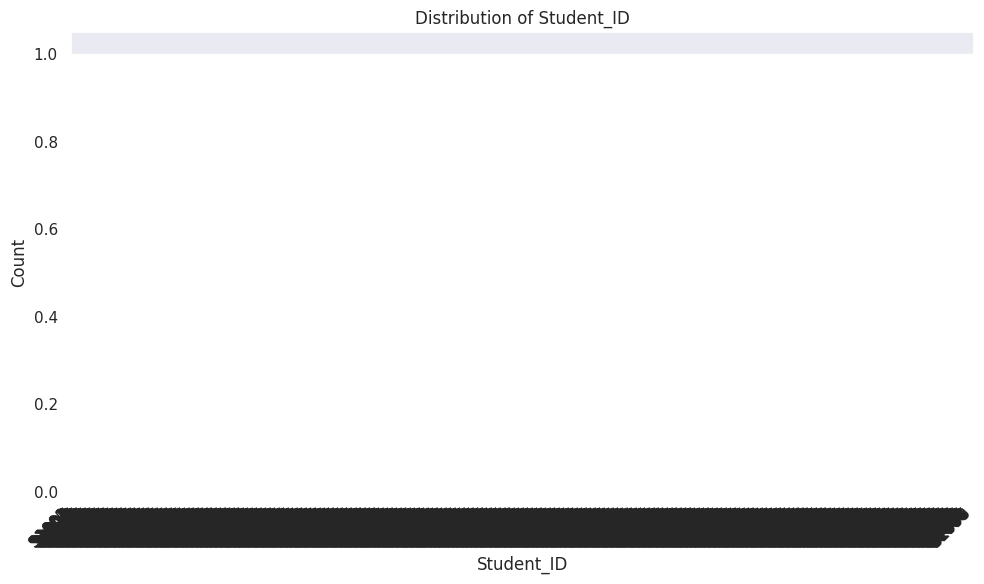

Value counts for Student_ID:
Student_ID
S2983    1
S2982    1
S2981    1
S2980    1
S2979    1
        ..
S1004    1
S1003    1
S1002    1
S1001    1
S1000    1
Name: count, Length: 2000, dtype: int64



In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

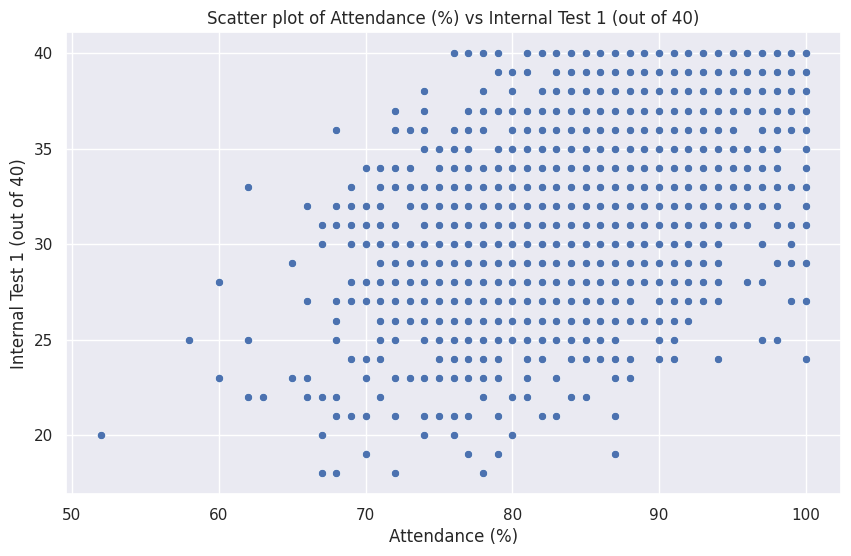

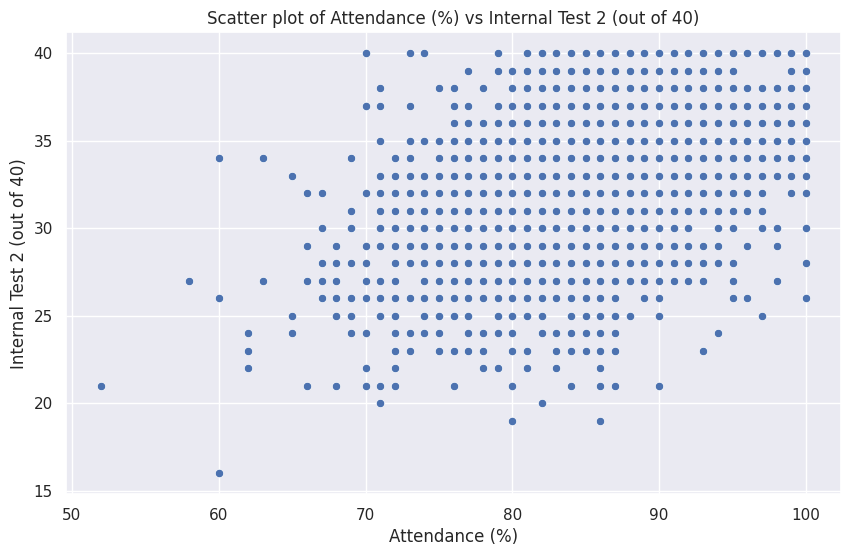

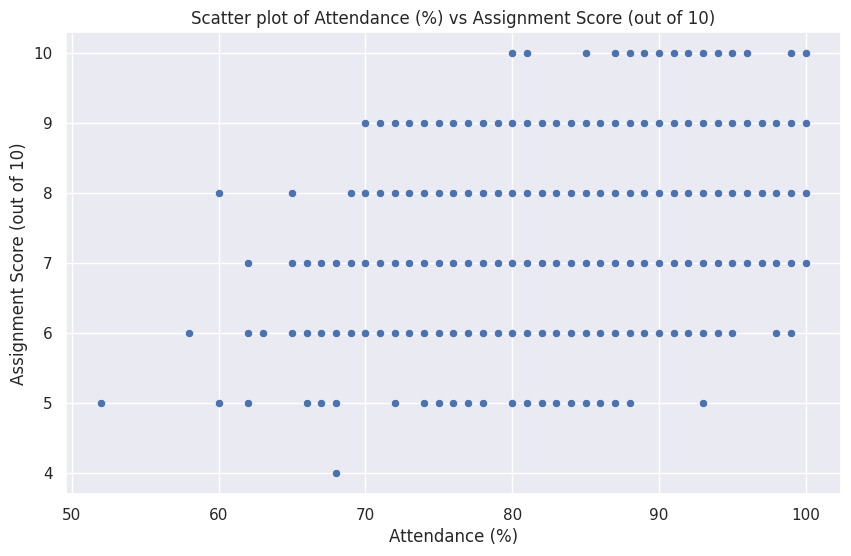

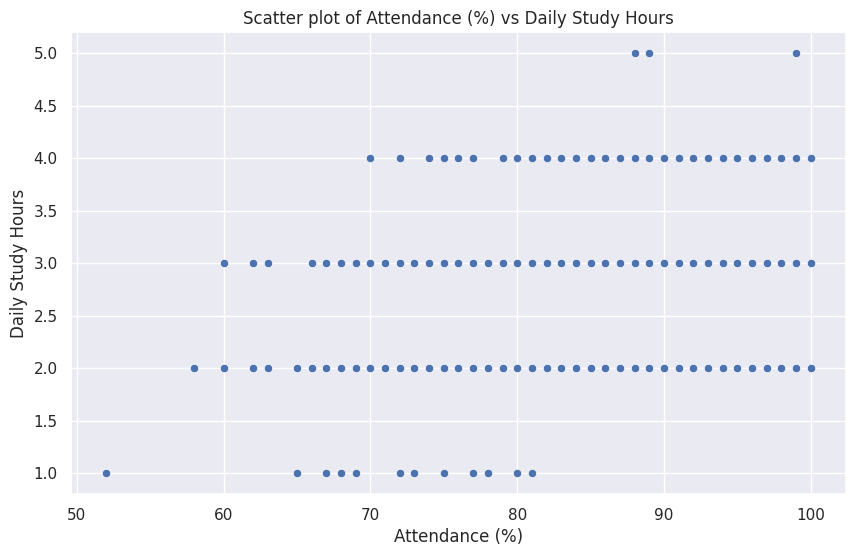

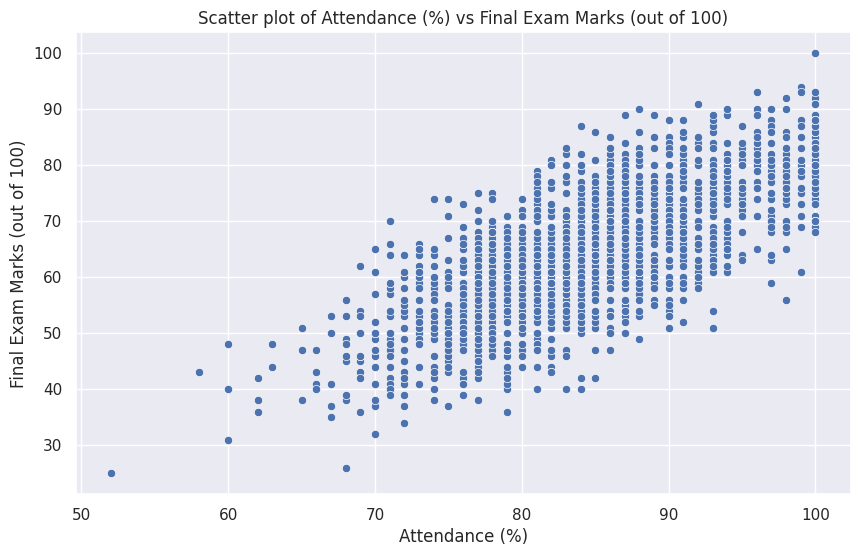

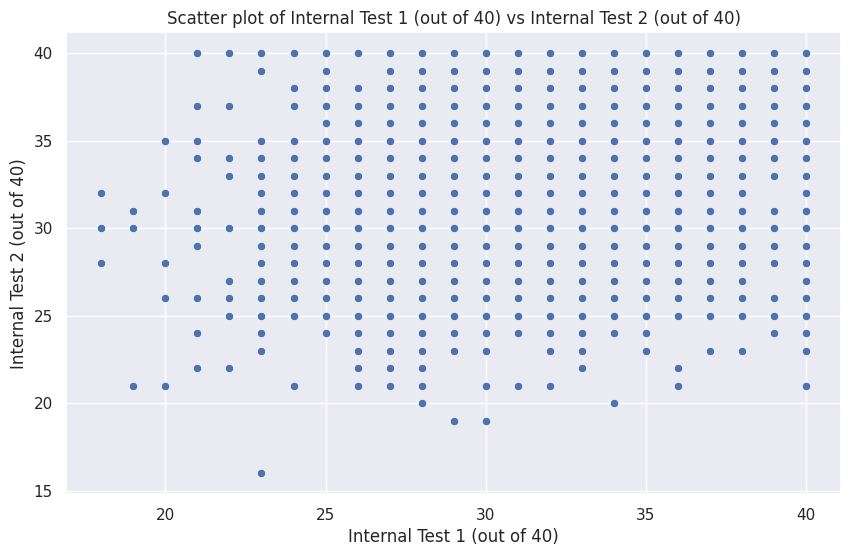

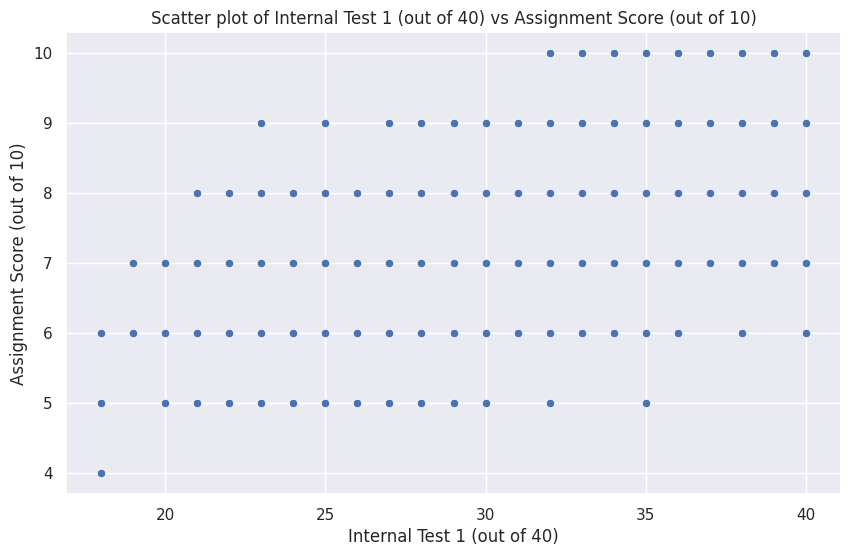

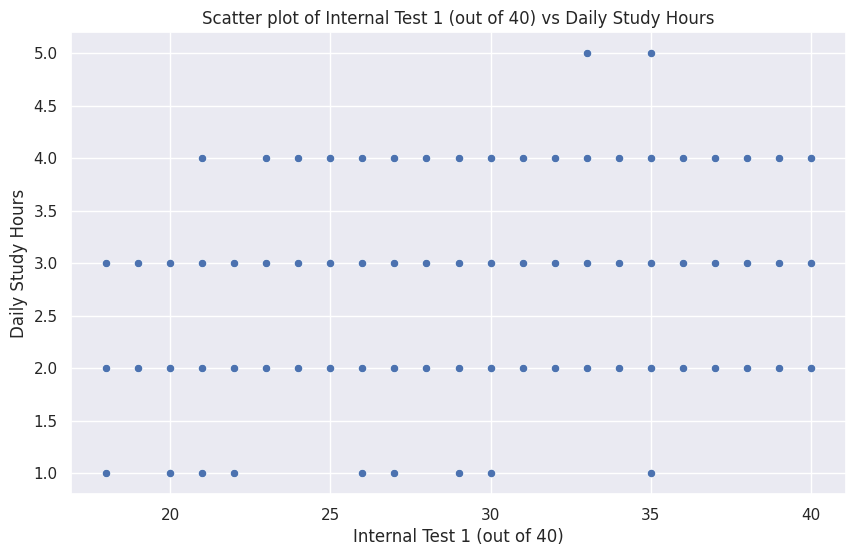

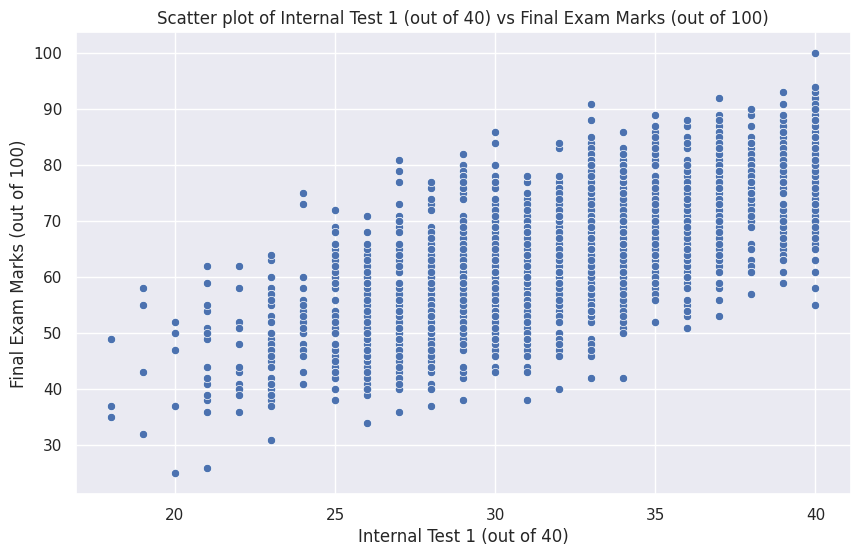

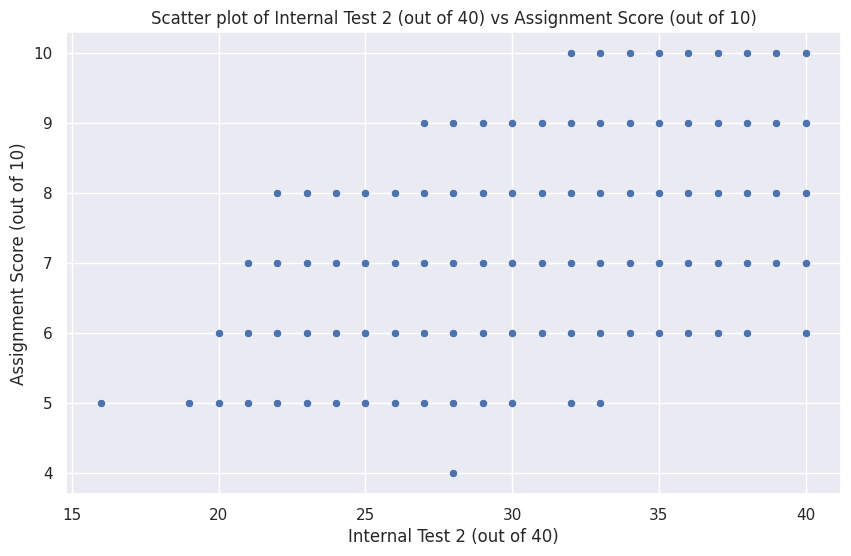

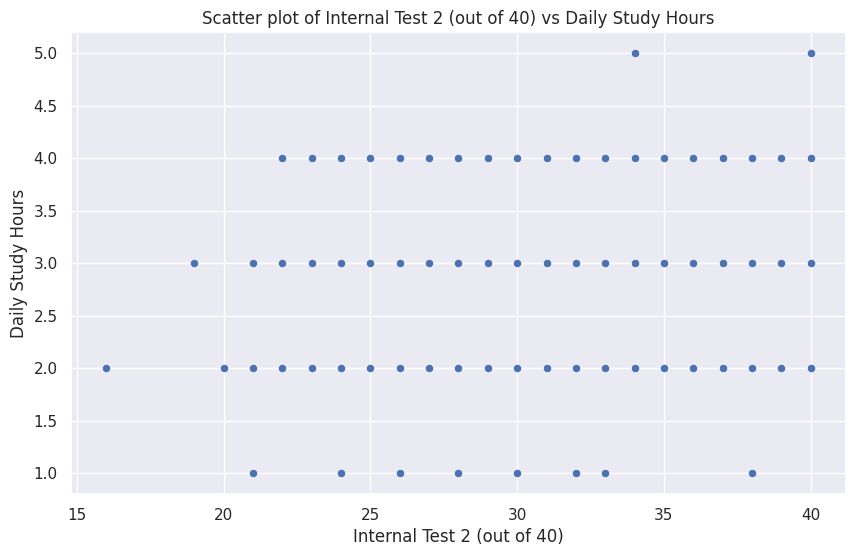

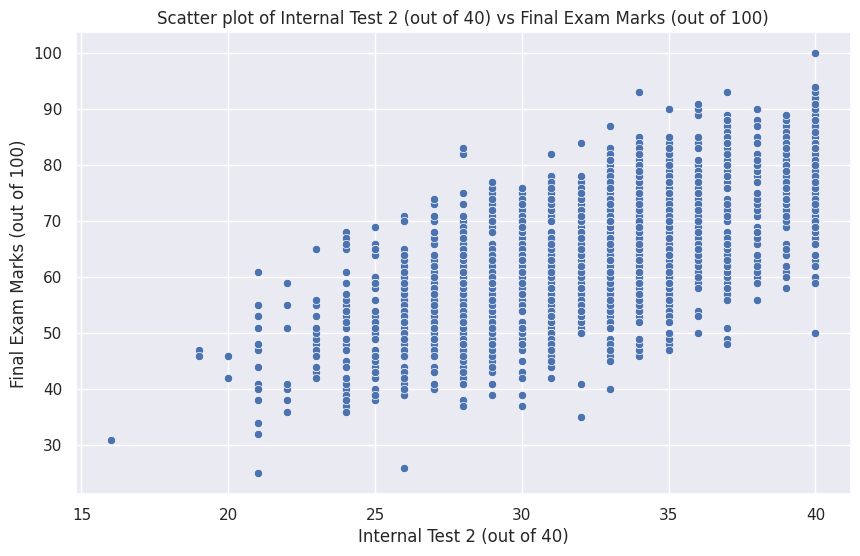

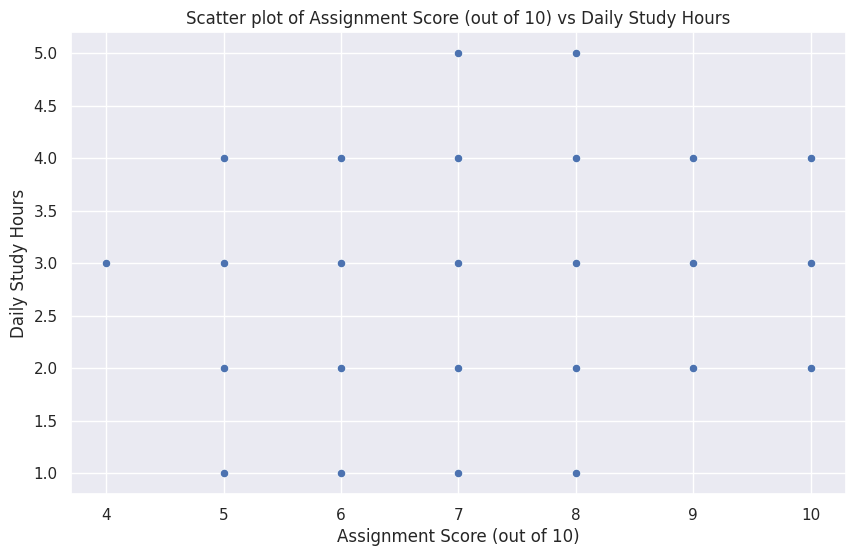

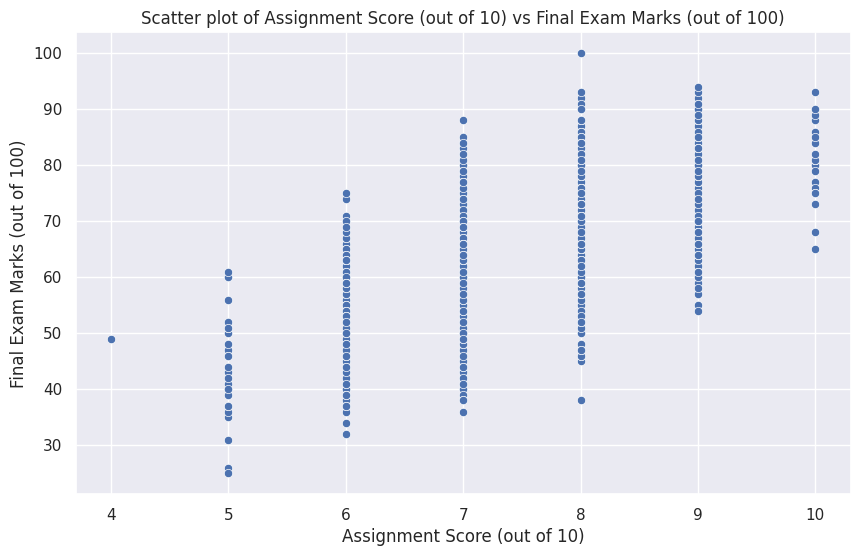

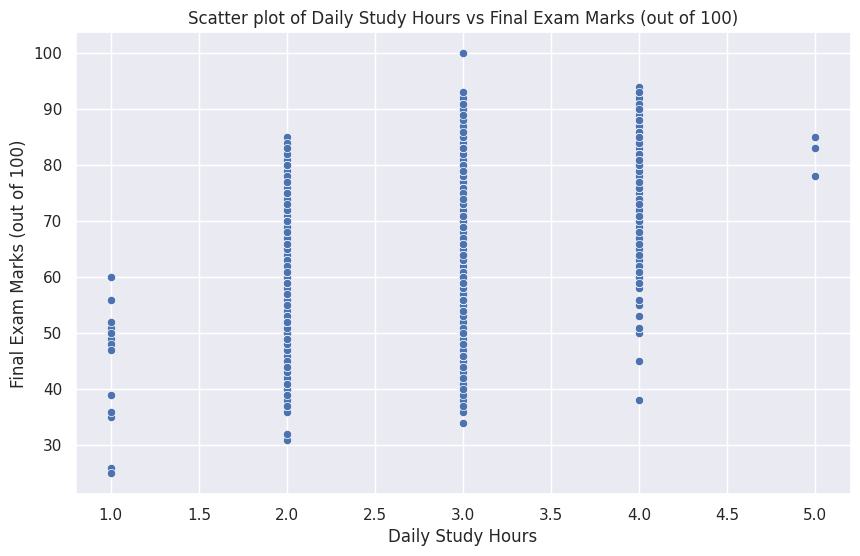

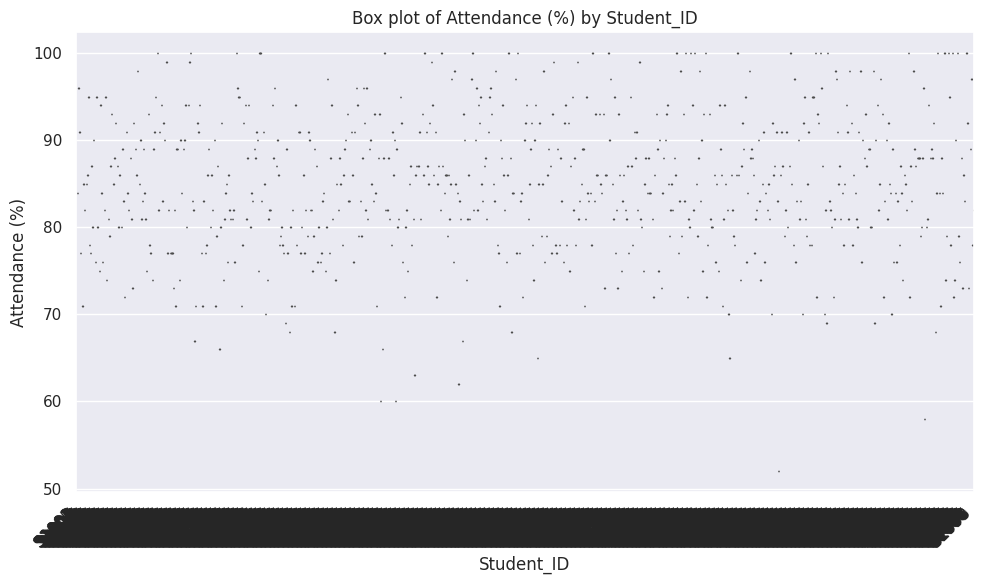

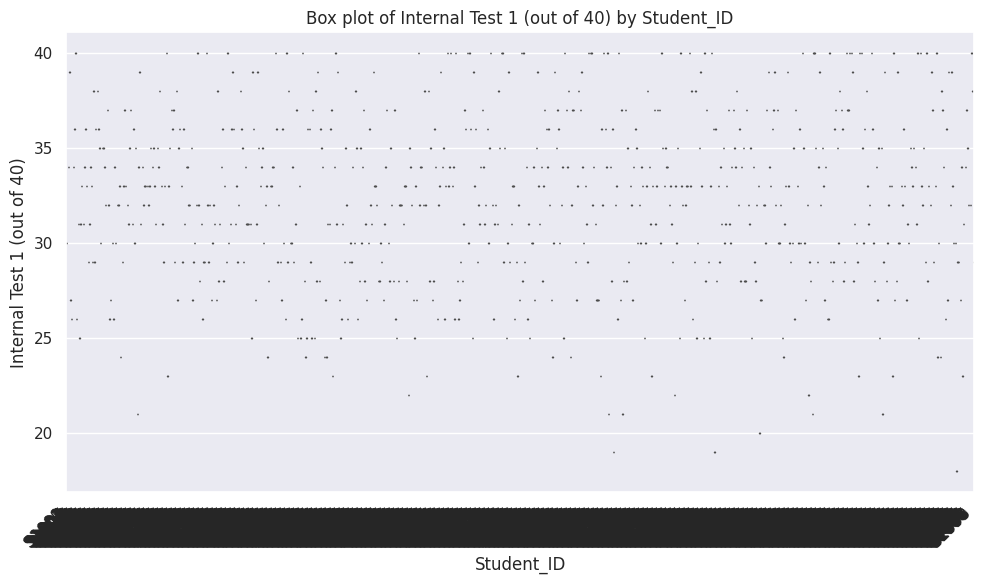

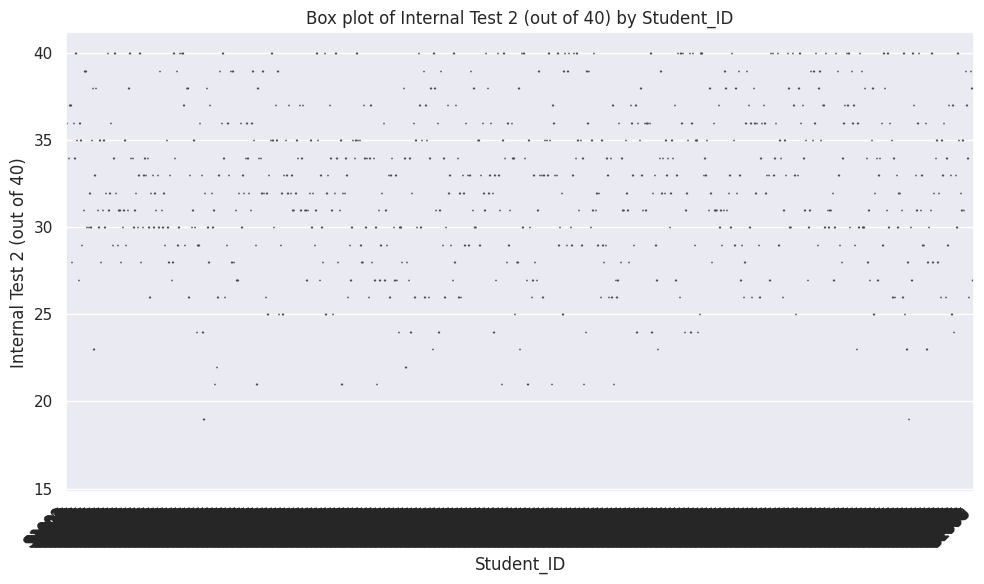

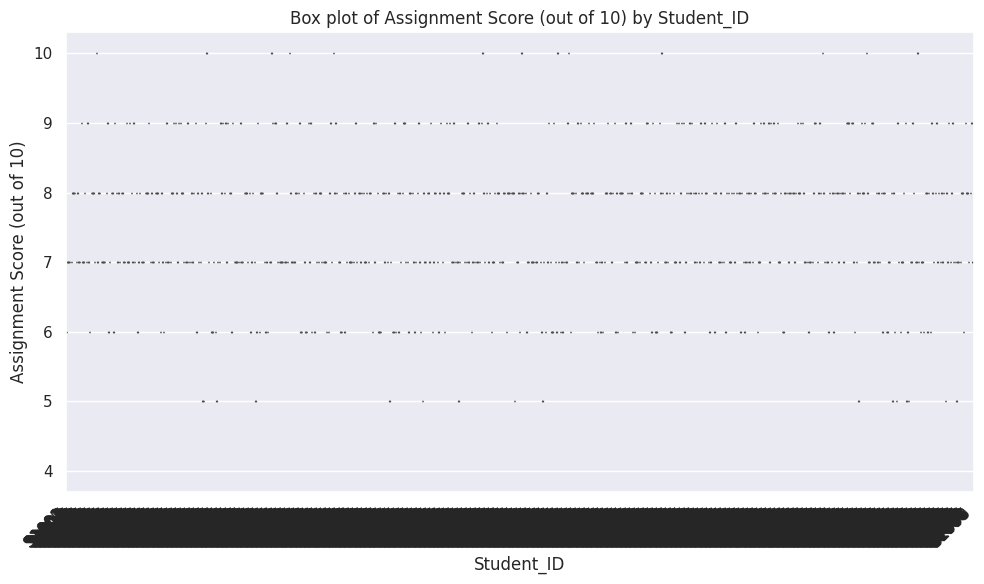

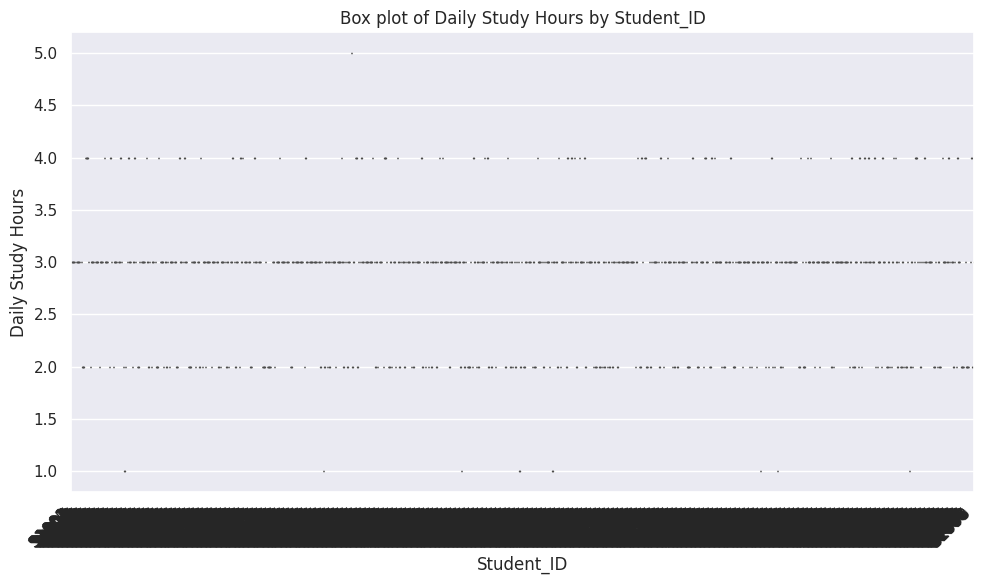

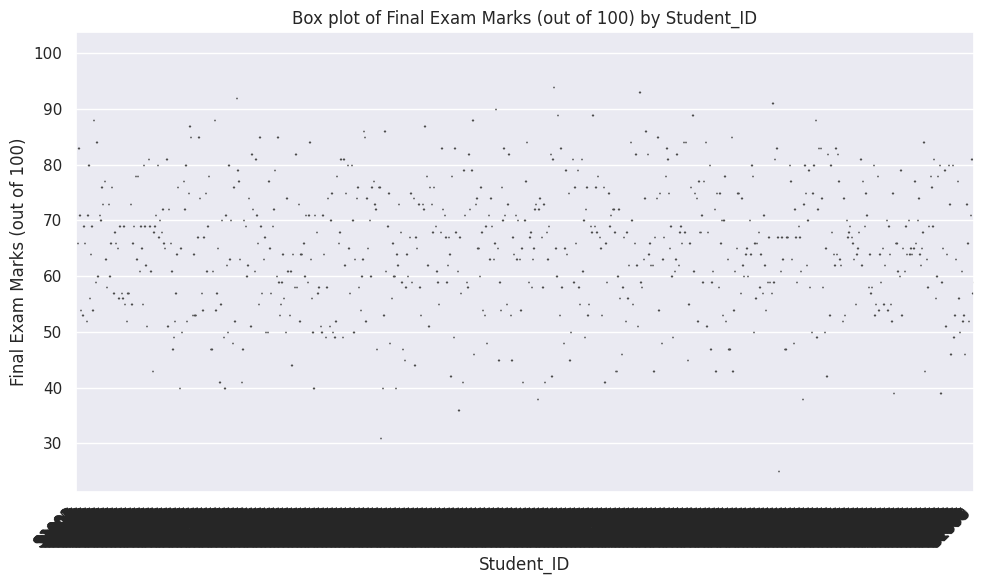

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

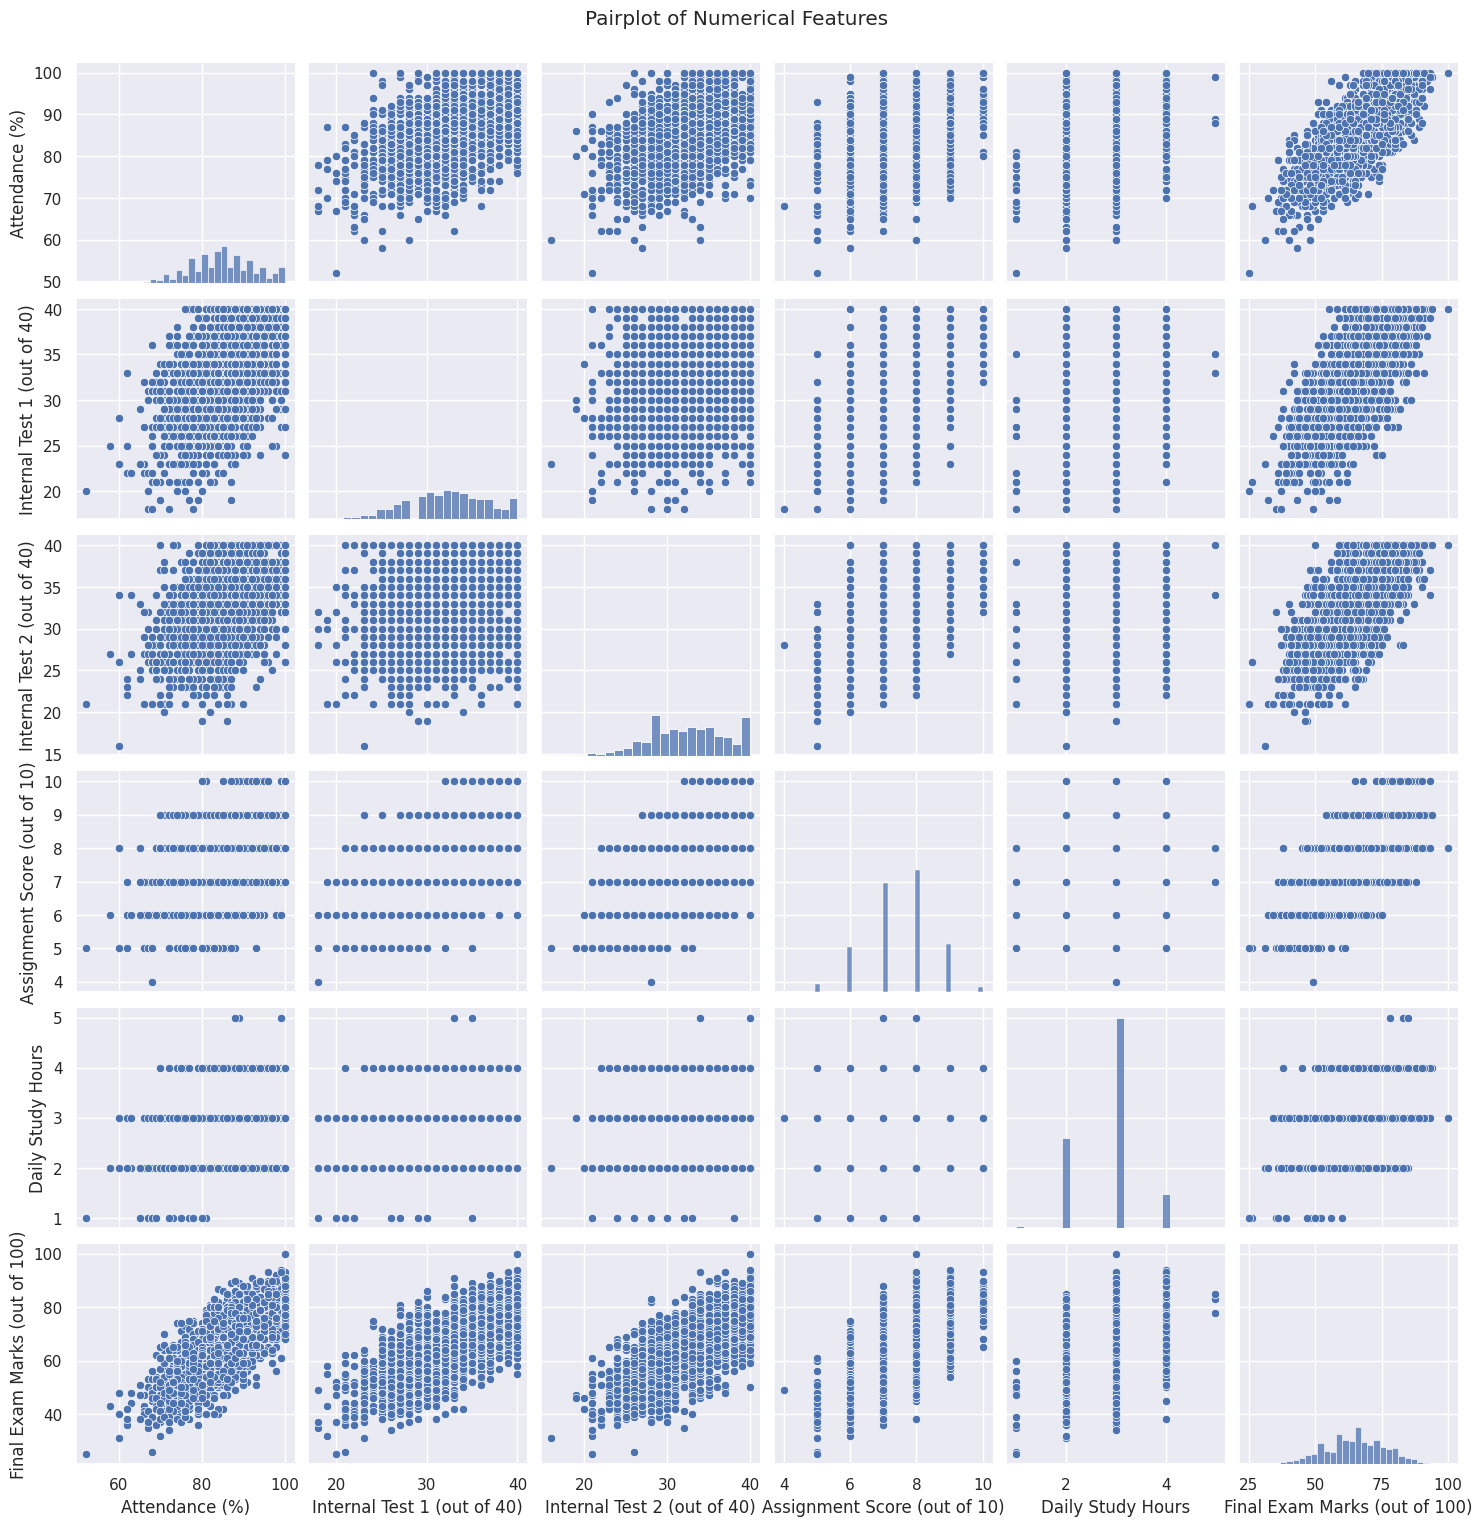

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

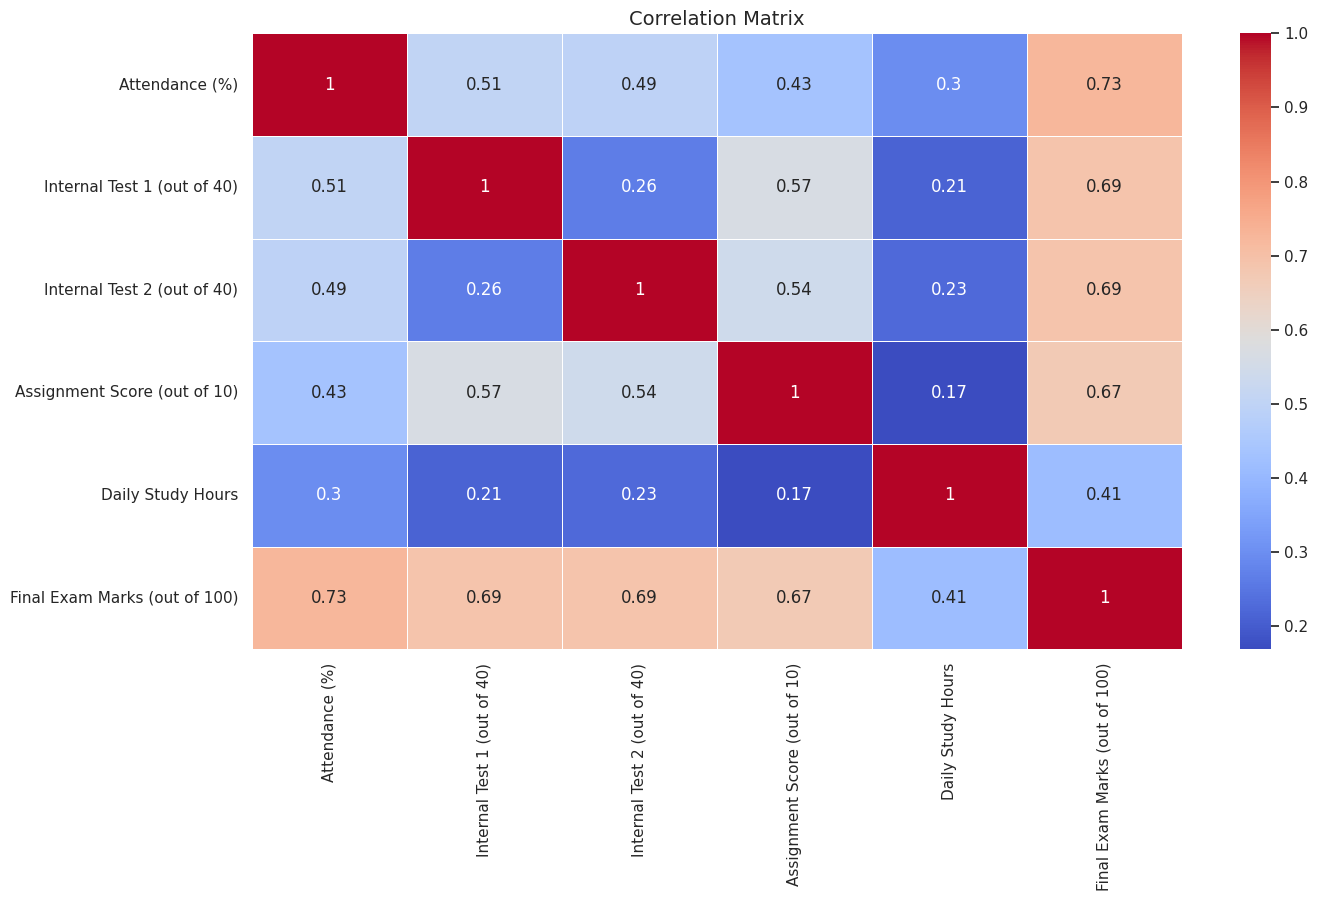

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You